In [ ]:
!pip install qiskit
!pip install qiskit_ibm_runtime
!pip install qiskit[visualization]
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha25

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_vector
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli
from qiskit_aer import AerSimulator

In [ ]:
# This is my noiseless environment. For the purpose of this experiment, this is the control variable. From my current understanding of Qiskit AER, method='statevector' indicates that the AER module tracks the quantum state at every step within the circuit. noise-free.
noiseless_sim = AerSimulator(method='statevector')

In [ ]:
#Trapped-ion
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error

noise_model_trapped_ion = NoiseModel() #This is an empty container that will hold all the error rules for trapped-ion simulation

t1, t2 = 1e6, 1e5  # Physical characteristics of trapped ion hardware, t1 is how long energy is held before decay and t2 is how long its position is maintained
gate_time_1q = 10 # how long it takes to execute a gate operation, single qubit gates are usually faster than double qubit gates
gate_time_2q = 100

error_1q = thermal_relaxation_error(t1, t2, gate_time_1q) # This takes the time values and mathematically calculates how much a qubit degrades during a single qubit operation
error_2q = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
           thermal_relaxation_error(t1, t2, gate_time_2q))

noise_model_trapped_ion.add_all_qubit_quantum_error(error_1q, ['u1','u2','u3','h','x']) # h refers to the hadamard gat, x is the bit flip gate, cx is the 2 qubit controlled NOT gate
noise_model_trapped_ion.add_all_qubit_quantum_error(error_2q, ['cx']) # all qubit quantum error means the rule applies to every qubit

trapped_ion_sim = AerSimulator(noise_model=noise_model_trapped_ion)

In [ ]:
# Neutral atom
noise_model_neutral_atom = NoiseModel()

t1, t2 = 1e4, 5e3 # T1 and T2 are shorter than Trapped ion in this instance
gate_time_1q = 1 # single qubit gate timing is much shorter here but double qubit is much longer (a known issue of Neutral Atom setup)
gate_time_2q = 250

error_1q = thermal_relaxation_error(t1, t2, gate_time_1q)
error_2q = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
           thermal_relaxation_error(t1, t2, gate_time_2q))

depol_error = depolarizing_error(0.005, 2) # simulated random error for Neutral Atom qubits, the chance it gets pushed into a random site. 0.5% chance of occuring and only occurs with 2 qubits
combined_2q = error_2q.compose(depol_error) # CLAUDE: This combines the thermal relaxation error and the depolarizing error into a single combined error model for two-qubit gates. .compose() stacks them together, meaning both types of error get applied when a two-qubit gate runs.

noise_model_neutral_atom.add_all_qubit_quantum_error(error_1q, ['u1','u2','u3','h','x'])
noise_model_neutral_atom.add_all_qubit_quantum_error(combined_2q, ['cx'])

neutral_atom_sim = AerSimulator(noise_model=noise_model_neutral_atom)

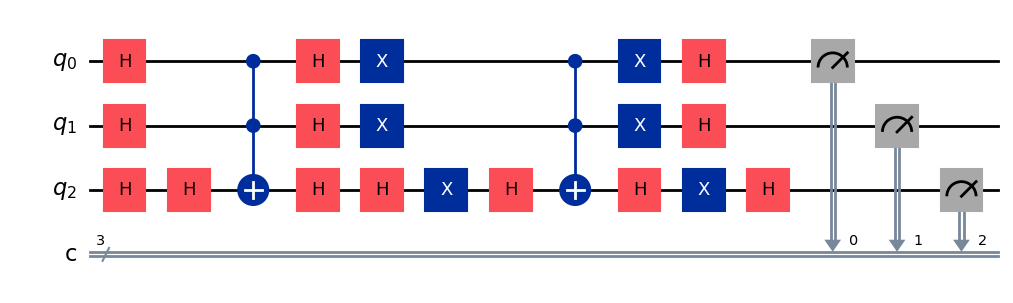

In [ ]:
# Grovers algorithm setup
from qiskit import QuantumCircuit, transpile #transpile actually bulids the circuit environment we are importing
from qiskit.visualization import plot_histogram
def build_grover_circuit(num_qubits, target_state):
    qc = QuantumCircuit(num_qubits, num_qubits)

    # Step 1: Hadamard layer
    for i in range(num_qubits):
        qc.h(i)

    # Step 2: Oracle
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)

    qc.h(num_qubits - 1)
    qc.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    qc.h(num_qubits - 1)

    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)

    # Step 3: Diffusion operator
    for i in range(num_qubits):
        qc.h(i)

    for i in range(num_qubits):
        qc.x(i)

    qc.h(num_qubits - 1)
    qc.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    qc.h(num_qubits - 1)

    for i in range(num_qubits):
        qc.x(i)

    for i in range(num_qubits):
        qc.h(i)

    # Step 4: Measurement
    qc.measure(range(num_qubits), range(num_qubits))

    return qc

qc = build_grover_circuit(3, '111')
qc.draw('mpl')



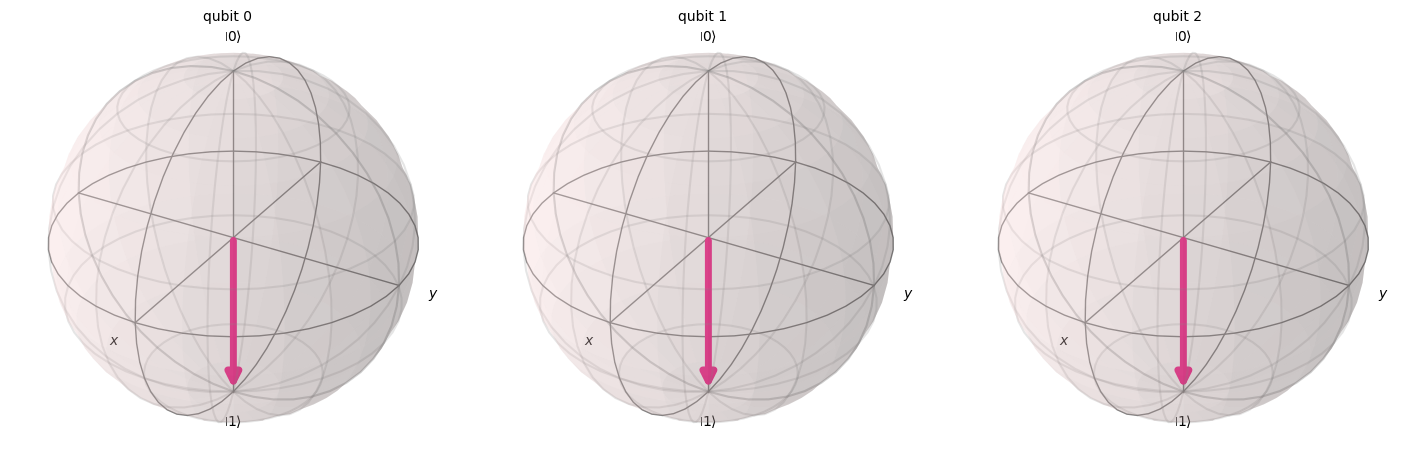

In [ ]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

qc_111 = QuantumCircuit(3)
qc_111.x(0)
qc_111.x(1)
qc_111.x(2)

state = Statevector.from_instruction(qc_111)


plot_bloch_multivector(state)

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Trial 1 (seed=42)
Noiseless: {'100': 36, '000': 19, '010': 29, '110': 40, '101': 37, '001': 30, '011': 39, '111': 794}
Trapped Ion: {'100': 33, '000': 20, '010': 32, '110': 36, '101': 42, '001': 31, '011': 42, '111': 788}
Neutral Atom: {'001': 83, '110': 112, '101': 120, '100': 89, '010': 99, '000': 53, '011': 75, '111': 393}



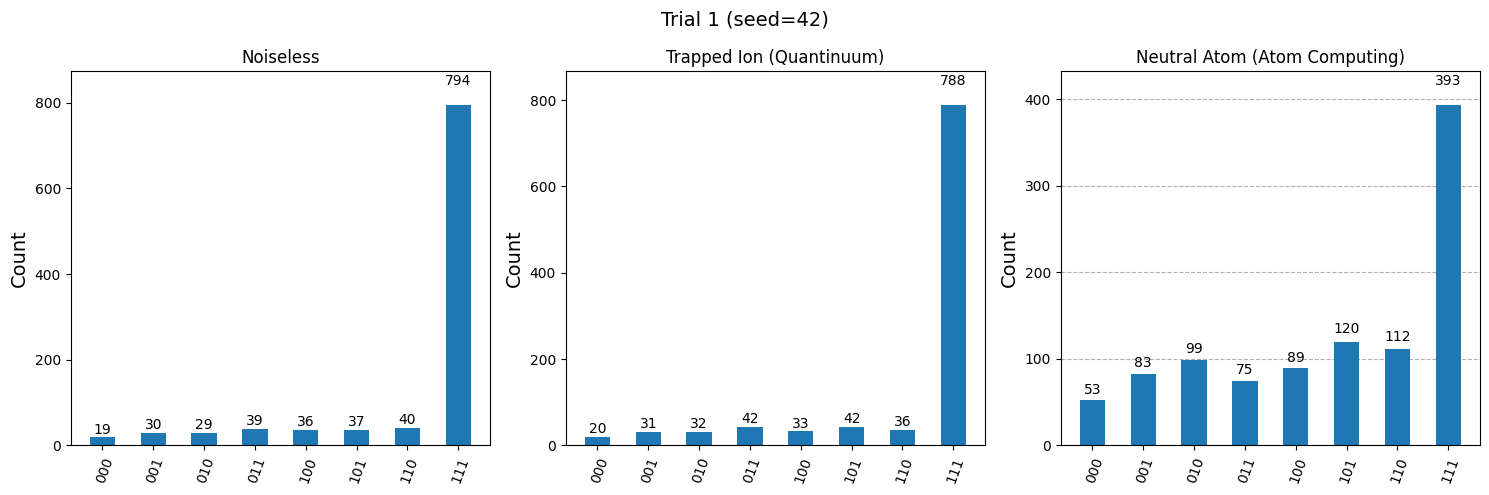

Trial 2 (seed=42)
Noiseless: {'100': 36, '000': 19, '010': 29, '110': 40, '101': 37, '001': 30, '011': 39, '111': 794}
Trapped Ion: {'100': 33, '000': 20, '010': 32, '110': 36, '101': 42, '001': 31, '011': 42, '111': 788}
Neutral Atom: {'001': 83, '110': 112, '101': 120, '100': 89, '010': 99, '000': 53, '011': 75, '111': 393}



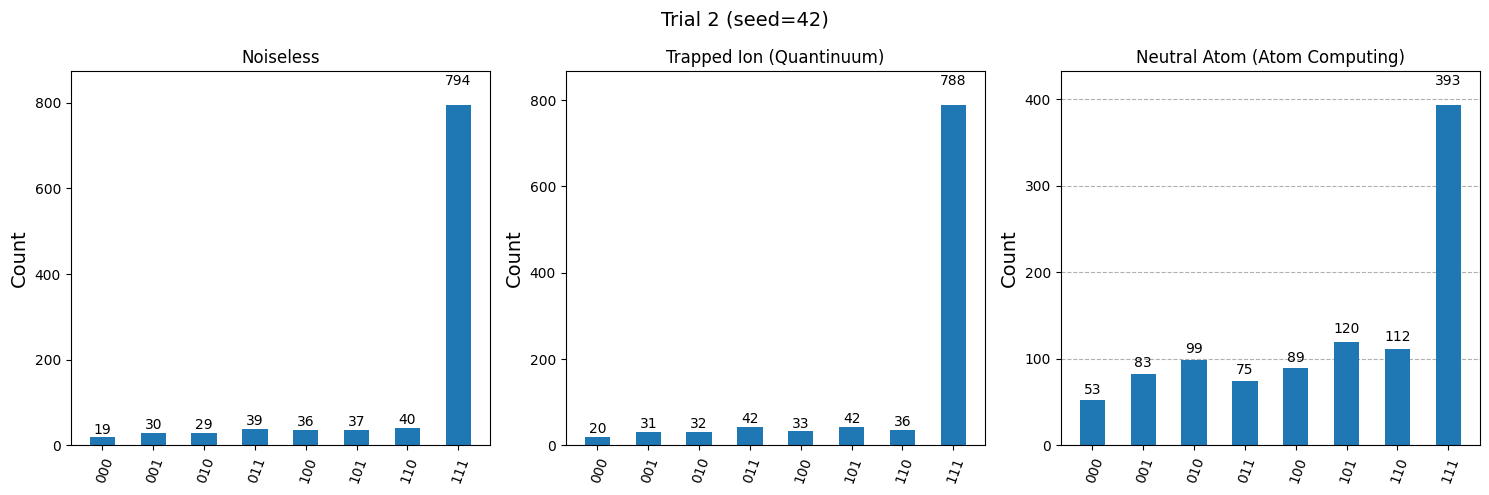

Trial 3 (seed=42)
Noiseless: {'100': 36, '000': 19, '010': 29, '110': 40, '101': 37, '001': 30, '011': 39, '111': 794}
Trapped Ion: {'100': 33, '000': 20, '010': 32, '110': 36, '101': 42, '001': 31, '011': 42, '111': 788}
Neutral Atom: {'001': 83, '110': 112, '101': 120, '100': 89, '010': 99, '000': 53, '011': 75, '111': 393}



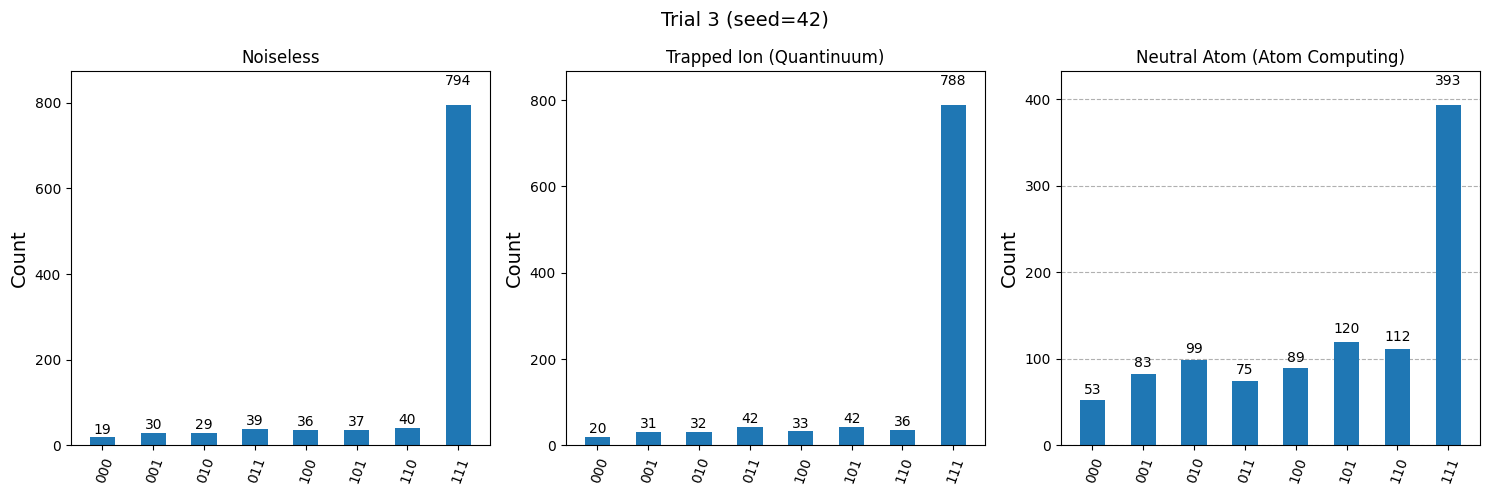

Trial 4 (seed=42)
Noiseless: {'100': 36, '000': 19, '010': 29, '110': 40, '101': 37, '001': 30, '011': 39, '111': 794}
Trapped Ion: {'100': 33, '000': 20, '010': 32, '110': 36, '101': 42, '001': 31, '011': 42, '111': 788}
Neutral Atom: {'001': 83, '110': 112, '101': 120, '100': 89, '010': 99, '000': 53, '011': 75, '111': 393}



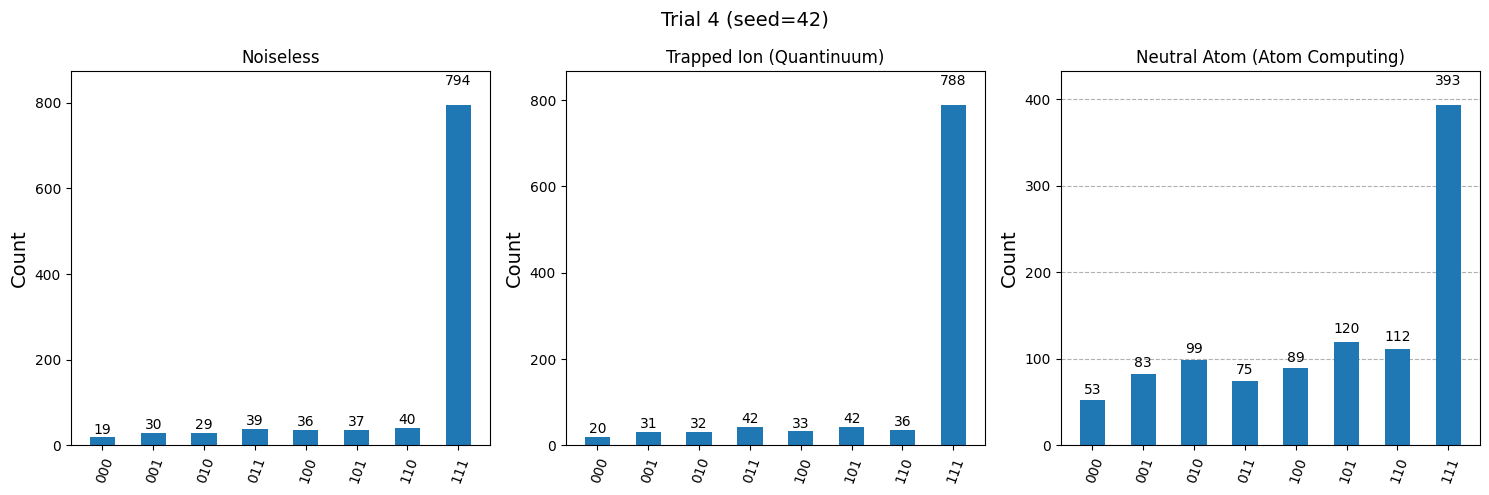

Trial 5 (seed=42)
Noiseless: {'100': 36, '000': 19, '010': 29, '110': 40, '101': 37, '001': 30, '011': 39, '111': 794}
Trapped Ion: {'100': 33, '000': 20, '010': 32, '110': 36, '101': 42, '001': 31, '011': 42, '111': 788}
Neutral Atom: {'001': 83, '110': 112, '101': 120, '100': 89, '010': 99, '000': 53, '011': 75, '111': 393}



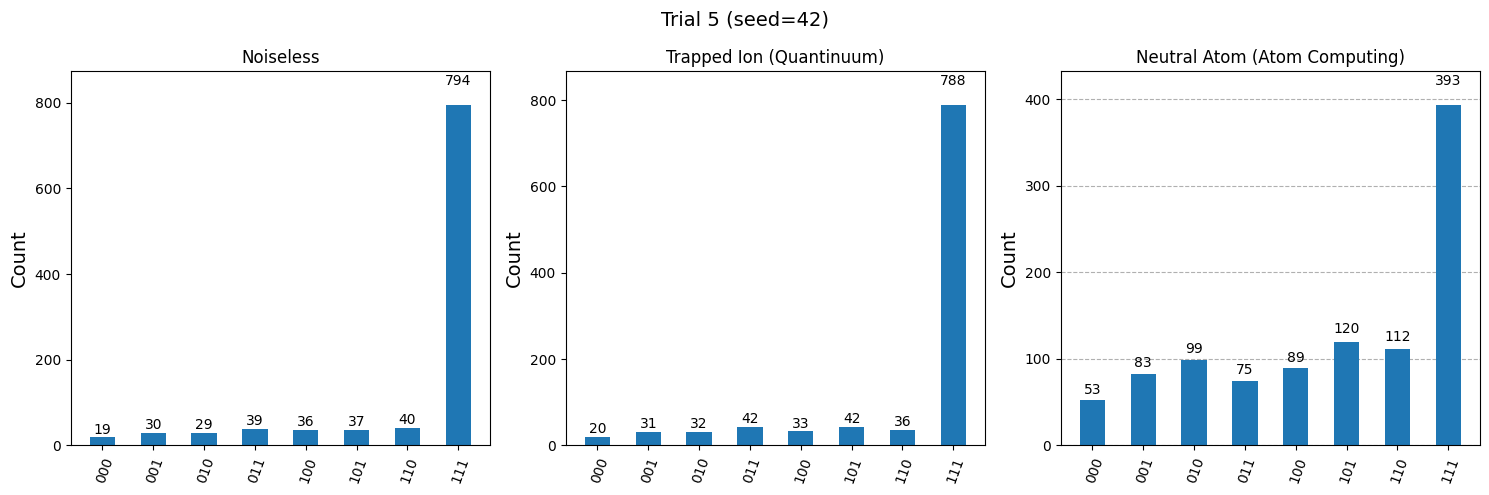

In [ ]:
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

seeds = [42, 42, 42, 42, 42]
shots = 1024

for trial, seed in enumerate(seeds, start=1):
    qc = build_grover_circuit(3, '111')

    transpiled_noiseless = transpile(qc, noiseless_sim)
    result_noiseless = noiseless_sim.run(transpiled_noiseless, shots=shots, seed_simulator=seed).result()
    counts_noiseless = result_noiseless.get_counts()

    transpiled_trapped = transpile(qc, trapped_ion_sim)
    result_trapped = trapped_ion_sim.run(transpiled_trapped, shots=shots, seed_simulator=seed).result()
    counts_trapped = result_trapped.get_counts()

    transpiled_neutral = transpile(qc, neutral_atom_sim)
    result_neutral = neutral_atom_sim.run(transpiled_neutral, shots=shots, seed_simulator=seed).result()
    counts_neutral = result_neutral.get_counts()

    print(f"Trial {trial} (seed={seed})")
    print("Noiseless:", counts_noiseless)
    print("Trapped Ion:", counts_trapped)
    print("Neutral Atom:", counts_neutral)
    print()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plot_histogram(counts_noiseless, ax=axes[0])
    plot_histogram(counts_trapped, ax=axes[1])
    plot_histogram(counts_neutral, ax=axes[2])
    axes[0].set_title('Noiseless')
    axes[1].set_title('Trapped Ion (Quantinuum)')
    axes[2].set_title('Neutral Atom (Atom Computing)')
    plt.suptitle(f'Trial {trial} (seed={seed})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'grover_results_trial_{trial}.png', dpi=300, bbox_inches='tight')
    plt.show()